In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/mai/Documents/Efrei M2/Project data science/data/marketing_and_sales.csv")
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [17]:
df.shape
df.columns
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4566 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


,TV,Radio,Social Media,Influencer,Sales
count,4562.000000,4568.000000,4566.000000,4572,4566.000000
unique,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,Mega,NaN
freq,NaN,NaN,NaN,1158,NaN
mean,54.066857,18.160356,3.323956,NaN,192.466602
std,26.125054,9.676958,2.212670,NaN,93.133092
min,10.000000,0.000684,0.000031,NaN,31.199409
25%,32.000000,10.525957,1.527849,NaN,112.322882
50%,53.000000,17.859513,3.055565,NaN,189.231172
75%,77.000000,25.649730,4.807558,NaN,272.507922


### Analyse exploratoire initiale

Le dataset contient 4572 campagnes marketing avec des variables représentant les budgets publicitaires (TV, Radio, Social Media) et le type d’influenceur.

La variable cible choisie est "Sales", ce qui correspond à un problème de régression.

L’analyse initiale met en évidence :
- la présence de valeurs manquantes dans plusieurs variables numériques
- des distributions cohérentes avec le contexte marketing
- une variable catégorielle ("Influencer") nécessitant un encodage

Ces observations guideront les étapes de preprocessing et de feature engineering.

In [18]:
df.duplicated().sum()
df.isnull().sum()

TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64

Aucune duplication n’a été détectée dans le dataset, ce qui garantit l’unicité des observations et évite un biais dans l’apprentissage du modèle.

In [19]:
# Vérification des valeurs manquantes : 
# numérique
for col in ["TV", "Radio", "Social Media", "Sales"]:
    df[col] = df[col].fillna(df[col].median())

# catégorielle
df["Influencer"] = df["Influencer"].fillna(df["Influencer"].mode()[0])

In [20]:
df.isnull().sum()

TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

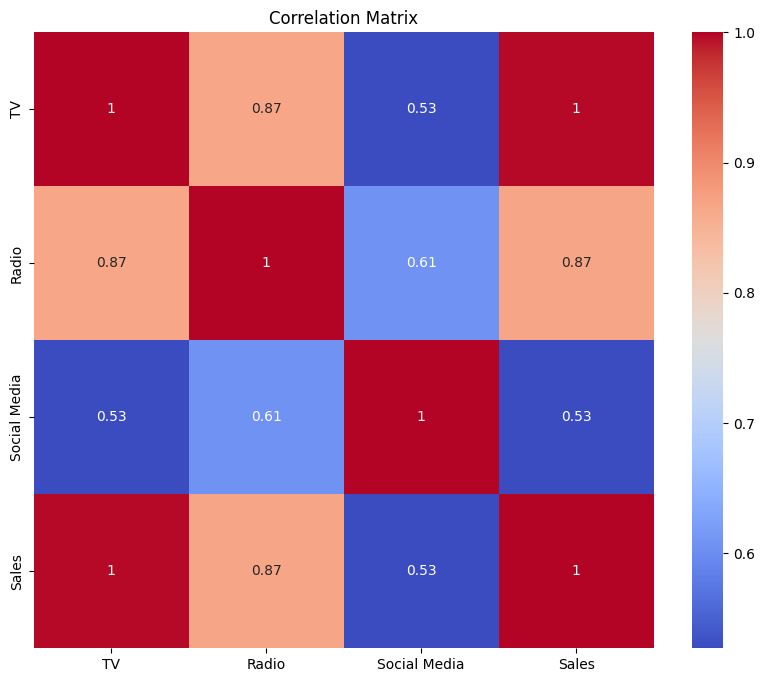

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [22]:
df[["TV", "Sales"]].head(20)
df[["TV", "Sales"]].corr()

,TV,Sales
TV,1.000000,0.996636
Sales,0.996636,1.000000


### Analyse des corrélations

La matrice de corrélation montre :

- Une très forte corrélation entre TV et Sales (~1.0)
- Une forte corrélation entre Radio et Sales (~0.87)
- Une corrélation modérée entre Social Media et Sales (~0.53)

Cela suggère que les budgets TV et Radio ont un impact significatif sur les ventes.

Cependant, la corrélation parfaite entre TV et Sales est inhabituelle et devra être analysée plus en détail, car elle peut indiquer une relation fortement linéaire ou une particularité du dataset.

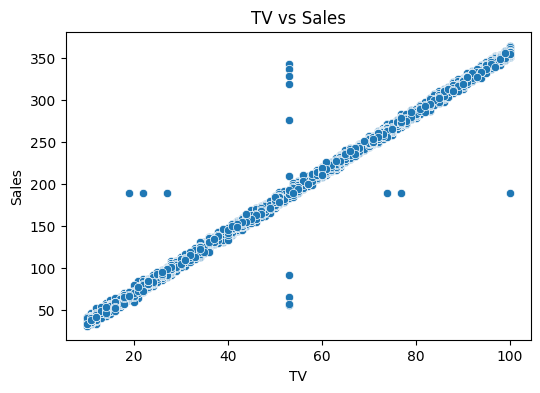

In [23]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="TV", y="Sales")
plt.title("TV vs Sales")
plt.show()

### Relation entre TV et Sales

Le graphique montre une relation linéaire très forte entre le budget TV et les ventes.

Plus le budget TV augmente, plus les ventes augmentent.

Quelques points atypiques sont présents, ce qui suggère que d’autres variables peuvent aussi influencer les ventes.

In [24]:
# Nettoyage des noms de colonnes :
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['tv', 'radio', 'social_media', 'influencer', 'sales'], dtype='object')

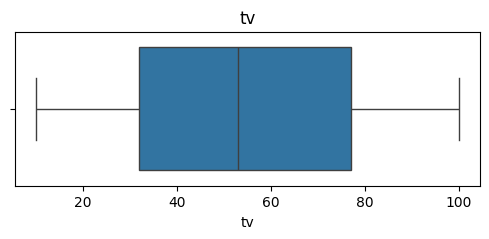

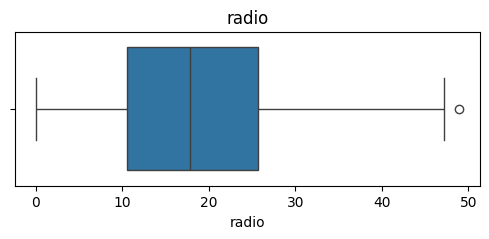

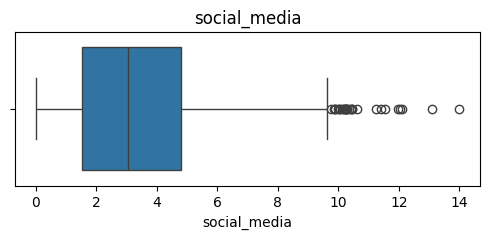

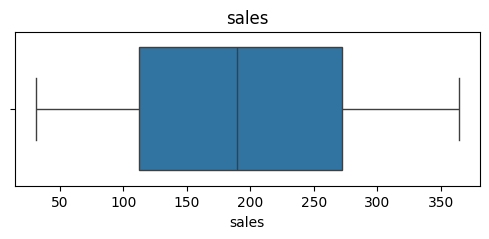

In [25]:
# Visualisation des distributions des variables numériques :
num_cols = ["tv", "radio", "social_media", "sales"]

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Analyse des boxplots

Les boxplots montrent que :

- Les variables TV et Sales ont des distributions assez équilibrées, sans valeurs extrêmes importantes.
- La variable Radio présente quelques valeurs atypiques élevées.
- La variable Social Media contient plusieurs outliers, indiquant certaines campagnes avec un budget particulièrement élevé.

Globalement, les données restent cohérentes et les valeurs extrêmes peuvent être conservées car elles peuvent représenter des cas réels importants.

## Feature Engineering

In [30]:
# Création de nouvelles fonctionnalités :
df["total_budget"] = df["tv"] + df["radio"] + df["social_media"]
df["tv_share"] = df["tv"] / df["total_budget"]
df["radio_share"] = df["radio"] / df["total_budget"]
df["social_media_share"] = df["social_media"] / df["total_budget"]
df["roi"] = df["sales"] / df["total_budget"]

# Interaction features :
df["tv_radio"] = df["tv"] * df["radio"]
df["tv_social"] = df["tv"] * df["social_media"]
df["radio_social"] = df["radio"] * df["social_media"]

### Création de nouvelles variables

De nouvelles variables ont été créées afin d’enrichir le dataset :

- total_budget : somme des investissements marketing
- parts de budget (tv_share, radio_share, social_media_share)
- roi : estimation du retour sur investissement
- interactions entre canaux marketing

Ces variables permettent de mieux capturer les relations entre les budgets et les ventes, ainsi que les effets combinés entre canaux.

In [28]:
# Exportation du DataFrame nettoyé : 
df.to_csv("../data/cleaned_marketing_and_data.csv", index=False)

In [29]:
# Encodage de la variable catégorielle "influencer" :
df_prepared = pd.get_dummies(df, columns=["influencer"], drop_first=True)
df_prepared.to_csv("../data/prepared_marketing_data.csv", index=False)